##  Исследование стартапов
### Цель и задачи  

**Цель:** Провести исследовательский анализ данных финансирования стартапов.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести инжиниринг признаков.
3. Провести исследовательский анализ данных:
    - изучить данные более детально.
4. Осуществить анализ динамики.
5. Сформулировать выводы по проведённому анализу.


### Данные

Для анализа поступили данные о финансировании стартапов. Данные состоят из двух датасетов:

- `cb_investments.csv` — информация о заведениях общественного питания;
- `cb_returns.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `cb_investments`

- `name` — название компании;
- `homepage_url` — ссылка на сайт компании;
- `category_list` — категории, в которых работает компания. Указываются через |;
- `market` — основной рынок или отрасль компании;
- `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
- `status` — текущий статус компании, например, operating, closed и так далее;
- `country_code` — код страны, например USA;
- `state_code` — код штата или региона, например CA;
- `region` — регион, например SF Bay Area;
- `city` — город, в котором расположена компания;
- `funding_rounds` — общее число раундов финансирования;
- `participants` — число участников в раундах финансирования;
- `founded_at` — дата основания компании;
- `founded_month` — месяц основания в формате YYYY-MM;
- `founded_quarter` — квартал основания в формате YYYY-QN;
- `founded_year` — год основания;
- `first_funding_at` — дата первого финансирования;
- `mid_funding_at` — дата среднего по времени раунда финансирования;
- `last_funding_at` — дата последнего финансирования;
- `seed` — сумма инвестиций на посевной стадии;
- `venture` — сумма венчурных инвестиций;
- `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
- `undisclosed` — сумма финансирования нераскрытого типа;
- `convertible_note` — сумма инвестиций через конвертируемые займы;
- `debt_financing` — сумма долгового финансирования;
- `angel` — сумма инвестиций от бизнес-ангелов;
- `grant` — сумма полученных грантов;
- `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
- `post_ipo_equity` — сумма финансирования после IPO;
- `post_ipo_debt` — сумма долгового финансирования после IPO;
- `secondary_market` — сумма сделок на вторичном рынке;
- `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
- `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

### Описание датасета `cb_returns`

- `year` — год возврата средств;
- `seed` — сумма возвратов от посевных инвестиций;
- `venture` — сумма возвратов от венчурных инвестиций;
- `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
- `undisclosed` — сумма возвратов нераскрытого типа;
- `convertible_note` — сумма возвратов через конвертируемые займы;
- `debt_financing` — сумма возвратов от долгового финансирования;
- `angel` — сумма возвратов бизнес-ангелам;
- `grant` — сумма возвратов по грантам;
- `private_equity` — сумма возвратов прямых (частных) вложений;
- `post_ipo_equity` — сумма возвратов от IPO;
- `post_ipo_debt` — сумма возвратов от долгового IPO;
- `secondary_market` — сумма возвратов от сделок на вторичном рынке;
- `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Структура проекта

1. Загрузка данных и знакомство с ними.
2. Инжиниринг признаков.
3. Исследовательский анализ данных.
4. Анализ динамики.
5. Итоговые выводы.

---


### 1. Знакомство с данными: загрузка и предобработка
#### 1.1. Вывод общей информации
Начнём с загрузки библиотек и датасетов `cb_investments` и `cb_returns`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `inv_df` и `returns_df`.

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

In [3]:
import os

# Пытаемся загрузить с локального пути, если нет - с серверного
try:
    inv_df = pd.read_csv('C:/Users/mobil/Downloads/cb_investments.zip', sep=';', low_memory=False)
    ret_df = pd.read_csv('C:/Users/mobil/Downloads/cb_returns.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    inv_df = pd.read_csv('/datasets/cb_investments.zip', sep=';', low_memory=False)
    ret_df = pd.read_csv('/datasets/cb_returns.csv')
    print("Серверная загрузка")

Локальная загрузка


Познакомимся с данными датасета `cb_investments.csv` — выведем первые строки методом `head().T`, а информацию о датафрейме методом `info()`:

In [4]:
#Первые 5 строк в транспонированном виде
inv_df.head(5).T

,0,1,2,3,4
name,Harvard University,University of New Brunswick,DuPont,University of Michigan,Case Western Reserve University
homepage_url,http://harvard.edu,http://www.unb.ca,http://www.dupont.com,http://www.umich.edu/,http://www.case.edu
category_list,|Education|,NaN,|Business Services|Agriculture|Automotive|Inve...,|Education|,|Education|
market,Education,NaN,Business Services,Education,Education
funding_total_usd,"9,00,00,000","20,00,000","90,00,000","77,00,000","5,40,000"
status,operating,operating,operating,operating,operating
country_code,USA,NaN,USA,USA,USA
state_code,MA,NaN,DE,MI,OH
region,Boston,NaN,"Wilmington, Delaware",Detroit,Cleveland
city,Cambridge,NaN,Wilmington,Ann Arbor,Cleveland


In [5]:
inv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
inv_df.nunique()

name                    49350
homepage_url            45850
category_list           16675
 market                   939
 funding_total_usd      14617
status                      3
country_code              115
state_code                 61
region                   1089
city                     4188
funding_rounds             17
participants               32
founded_at               3369
founded_month             420
founded_quarter           218
founded_year              149
first_funding_at         3914
mid_funding_at           3106
last_funding_at          3657
seed                     3337
venture                  9300
equity_crowdfunding       252
undisclosed               687
convertible_note          299
debt_financing           1872
angel                     999
grant                     532
private_equity            847
post_ipo_equity           239
post_ipo_debt              57
secondary_market           20
product_crowdfunding      176
round_A                  2035
round_B   

Датасет `cb_investments.csv` содержит 54294 строк и 40 столбцов. Пропуски есть во всех столбцах и они занимают достаточно большую часть данных. Уже можно увидеть, как в конечных колонках `round_A` – `round H` с каждым раундом всё меньше уникальных значений вплоть до 5 в последней. По данным видно, что многие ячейки также заполнены нулевыми значениями. Почти все названия приведены в правильном виде и соотвествуют своим значениям, но надо убрать пробелы перед `market` и `funding_total_usd`.

In [7]:
ret_df[:5]

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
ret_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
ret_df.nunique()

year                    15
seed                    15
venture                 15
equity_crowdfunding     10
undisclosed             15
convertible_note        12
debt_financing          15
angel                   14
grant                    1
private_equity          14
post_ipo_equity         15
post_ipo_debt            5
secondary_market        14
product_crowdfunding     7
dtype: int64

Датасет `cb_returns.csv` содержит 15 строк и 14 столбцов. Все столбцы без пропусков и их названия соответствуют содержимому.

#### 1.2. Предобработка данных

In [10]:
# Убираем пробелы в начале и конце названий колонок
inv_df.columns = inv_df.columns.str.strip()

Теперь поработаем со столбцом `funding_total_usd` и уберем в нем лишние мешающие значения и переведем к числовому типу.

In [11]:
# Сначала чистим: убираем запятые и пробелы
inv_df['funding_total_usd'] = inv_df['funding_total_usd'].str.replace(',', '', regex=False).str.strip()

# Потом конвертируем, ошибки заменяем на NaN
inv_df['funding_total_usd'] = pd.to_numeric(inv_df['funding_total_usd'], errors='coerce')

Следующим шагом переведем столбцы с датой и временем в правильный формат и тип данных, так как сейчас они отображаются как object.

In [12]:
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_columns:
    inv_df[col] = pd.to_datetime(inv_df[col], format='%Y-%m-%d', errors='coerce')

In [13]:
inv_df['founded_at'].head(5)

0          NaT
1   1785-01-01
2   1802-07-19
3   1817-01-01
4   1826-01-01
Name: founded_at, dtype: datetime64[ns]

Данные приведены к формату '%Y-%m-%d', но увиденные выше даты похожи на выбросы.

Установим в `ret_df` столбец `year` как индекс для удобства.

In [14]:
# Устанавливаем столбец year как индекс
ret_df = ret_df.set_index('year')

Проведем предобработку текстовых столбцов, необходимо, чтобы их пропуски были заполнены заглушкой 'unknown', все содержимое написано с маленькой буквы и в них отстутствавали лишние пробелы.

In [15]:
# Текстовые столбцы (object)
text_cols = inv_df.select_dtypes(include=['object']).columns

# Заполняем пропуски заглушкой 'unknown'
for col in text_cols:
    inv_df[col] = inv_df[col].fillna('unknown')

In [16]:
# Для единообразия
for col in ['category_list', 'market', 'status', 'country_code']:
    inv_df[col] = inv_df[col].str.lower()

In [17]:
# Убираем пробелы в начале и конце всех текстовых колонок
for col in text_cols:
    inv_df[col] = inv_df[col].str.strip()

In [18]:
# Проверяем, остались ли пропуски
inv_df[text_cols].isna().sum()

name               0
homepage_url       0
category_list      0
market             0
status             0
country_code       0
state_code         0
region             0
city               0
founded_month      0
founded_quarter    0
dtype: int64

Теперь займемся дубликатами в датафрейме `inv_df`. Посчитаем сколько их было изначально и удалим.

In [19]:
# Проверяем количество дубликатов
print(f"Дубликатов до удаления: {inv_df.duplicated().sum()}")

# Удаляем полные дубликаты
inv_df = inv_df.drop_duplicates()

print(f"Размер после удаления дубликатов: {inv_df.shape}")

Дубликатов до удаления: 4855
Размер после удаления дубликатов: (49439, 40)


Также проверим столбец `funding_total_usd` на наличие пропусков и удалим строки, где нет данных о финансировании

In [20]:
# Проверяем сколько пропусков
print(f"Пропусков в funding_total_usd: {inv_df['funding_total_usd'].isna().sum()}")

# Удаляем строки, где нет данных о финансировании
inv_df = inv_df.dropna(subset=['funding_total_usd'])

Пропусков в funding_total_usd: 8532


Из 49438 строк осталось 40907 строк после удаления пропусков в `funding_total_usd`.
То есть 8 531 компаний (17%) не имели данных о финансировании и были удалены. Это нормально для нашего анализа.

Заполним пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

In [21]:
inv_df[['first_funding_at',
        'mid_funding_at',
        'last_funding_at']].isna().sum()

first_funding_at        2
mid_funding_at      13676
last_funding_at         0
dtype: int64

In [22]:
missing = inv_df['mid_funding_at'].isna()

inv_df.loc[missing, 'mid_funding_at'] = (
    inv_df.loc[missing, 'first_funding_at']
    + (inv_df.loc[missing, 'last_funding_at']
       - inv_df.loc[missing, 'first_funding_at']) / 2
)

In [23]:
inv_df['mid_funding_at'].isna().sum()

np.int64(1)

In [24]:
inv_df[inv_df['mid_funding_at'].isna()][
    ['first_funding_at', 'mid_funding_at', 'last_funding_at']
]

,first_funding_at,mid_funding_at,last_funding_at
33041,NaT,NaT,2014-09-25


В столбце mid_funding_at было обнаружено 13 676 пропусков. Для их заполнения использовалась середина интервала между датами первого и последнего раунда финансирования. После заполнения остался только 1 пропуск, который невозможно восстановить из-за отсутствия одной из необходимых дат.

Посмотрим на то, сколько данных было отброшено после предобработки в абсолютном и относительном значениях.

In [25]:
initial = 54294
after_clean = 40907
dropped = initial - after_clean
percent = (dropped / initial) * 100

print(f"Отброшено строк: {dropped}")
print(f"Процент отброшенных данных: {percent:.1f}%")

Отброшено строк: 13387
Процент отброшенных данных: 24.7%


In [26]:
inv_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          40907 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month        

Отброшено ~24.7% данных (около четверти). Это умеренная потеря, приемлемая для анализа инвестиций, так как удалялись строки без информации о финансировании. Зато теперь большинство строк не имеют пропусков и данные оптимизированы для дальнейшей работы.

#### 1.3 Промежуточные выводы после предобработки

- Датафрейм `inv_df` содержит 40907 значений, 40 столбцов. Теперь только 4 столбца содержат пропуски, что предоставляет удобство при работе с данными.
- С помощью удаления пропусков было отброшено 24.7%(13387) данных в этом датафрейме.
- В столбце `funding_total_usd` было удалено 8531 строк (компаний без информации о финансировании), что позволило отбросить ненужную информацию.
- Были оптимизированы временные и текстовые значения в столбцах для дальнейшей работы с ними. Они приведены к единому формату и удалены лишние пробелы.
- Столбец `mid_funding_at` содержал огромное количество пропусков (13676), которые были заполнены приблизительно середину интервала между `first_funding_at` и `last_funding_at`, в результате чего остался один пропуск.
- В датафрейме `ret_df` столбец year принял значение индекса. Датафрейм содержит 15 строк и 14 столбцов.

---

###  Шаг 2. Инжиниринг признаков
#### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:
- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

Для этого создадим новый столбец `funding_period_group`, который будет отображать принадлежность к одной из этих групп. С помощью функции определим группу каждой компании:

In [27]:
# Функция для определения группы
def classify_funding_period(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    
    if pd.isna(row['first_funding_at']) or pd.isna(row['last_funding_at']):
        return 'Нет данных о датах'
    
    days_diff = (row['last_funding_at'] - row['first_funding_at']).days
    
    if days_diff <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

inv_df['funding_period_group'] = inv_df.apply(classify_funding_period, axis=1)

Создадим столбчатую диаграмму, чтобы наглядно увидеть разницу между количеством компаний в группах.

In [28]:
inv_df['funding_period_group'].value_counts()

funding_period_group
Единичное финансирование          24113
Срок финансирования более года    12291
Срок финансирования до года        4501
Нет данных о датах                    2
Name: count, dtype: int64

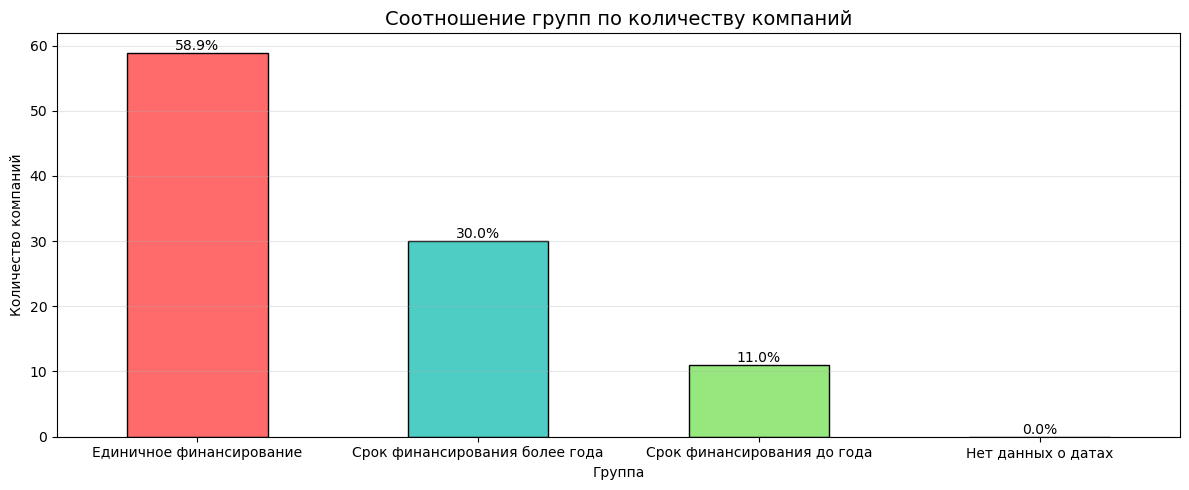

In [29]:
counts = inv_df['funding_period_group'].value_counts()
percentages = (counts / counts.sum()) * 100

plt.figure(figsize=(12, 5))
ax = percentages.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#95E77E'], edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='edge') 
plt.title('Соотношение групп по количеству компаний', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Количество компаний')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

На графике видно, что доминирует единичное финансирование (24112 - 58.9%), почти в два раза меньше срок финансирования более года (12291 - 30%), сильно меньше срок финансирования до года (4501 - 11%) и нет данных о датах только в двух компаниях.

Следующий график будет отражать соотношение компаний по объему инвестиций, чтобы понять, какая группа вкладывает больше средств. 

In [30]:
investment_by_group = inv_df.groupby('funding_period_group')['funding_total_usd'].sum().sort_values(ascending = False) / 1e9
print(investment_by_group.round(1))
print("(млрд $)")

funding_period_group
Срок финансирования более года    402.7
Единичное финансирование          199.3
Срок финансирования до года        48.9
Нет данных о датах                  0.0
Name: funding_total_usd, dtype: float64
(млрд $)


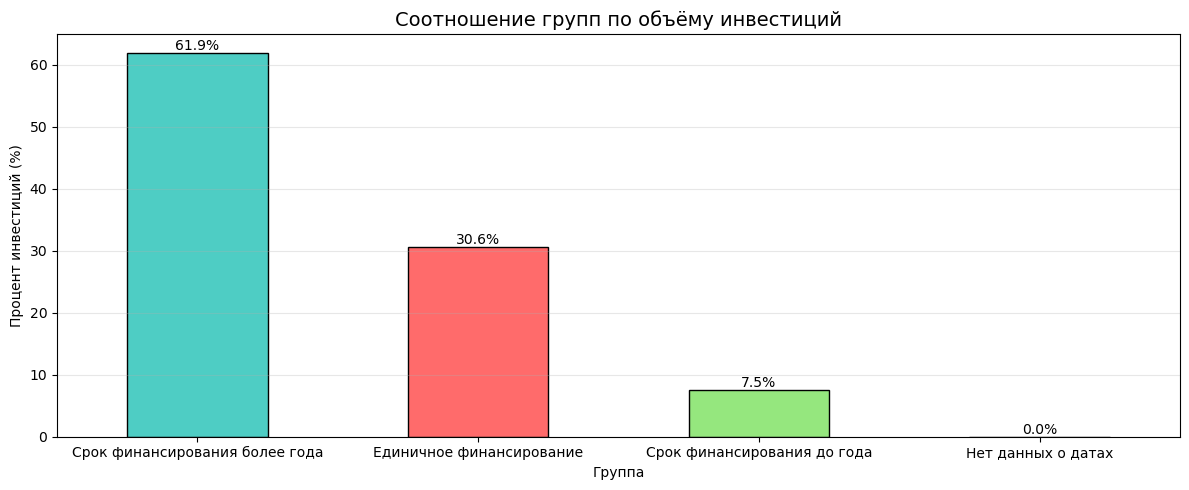

In [31]:
investment_by_group = inv_df.groupby('funding_period_group')['funding_total_usd'].sum().sort_values(ascending = False)
investment_percentages = (investment_by_group / investment_by_group.sum()) * 100

plt.figure(figsize=(12, 5))
ax = investment_percentages.plot(kind='bar', color=['#4ECDC4','#FF6B6B', '#95E77E'], edgecolor='black')
plt.title('Соотношение групп по объёму инвестиций', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Процент инвестиций (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Добавляем проценты на столбцы с помощью bar_label
ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='edge')

plt.tight_layout()
plt.show()

В итоге, результаты очень поменяли ситуацию, больше всего инвестиций идет за "срок финансирования более года", несмотря на то что эта группа включает в себя лишь 30% компаний. 

#### 2.2 Выделение средних и нишевых сегментов рынка

Далее необходимо выделить сегменты рынка. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно – к средним, а сегменты до 35 компаний отнесем к нишевым.

In [32]:
# Посмотрим на отображение сегментов и количества компаний в них
inv_df['market'].value_counts()

market
software              4812
biotechnology         3590
unknown               2503
mobile                2344
e-commerce            1866
                      ... 
flash storage            1
project management       1
portals                  1
service industries       1
gold                     1
Name: count, Length: 395, dtype: int64

In [33]:
# Функция для определения сегментов рынка
market_counts = inv_df['market'].value_counts()

def classify_market(count):
    if count > 120:
        return 'Массовый сегмент'
    
    elif (count >= 35) and (count <= 120):
        return 'Средний сегмент'

    else:
        return 'Нишевый сегмент'

market_segment = market_counts.apply(classify_market)

inv_df['market_segment'] = inv_df['market'].map(market_segment)

Далее отдельно рассмотрим массовые сегменты (более 120 компаний) и изобразим на графике распределение сегментов по количеству компаний.

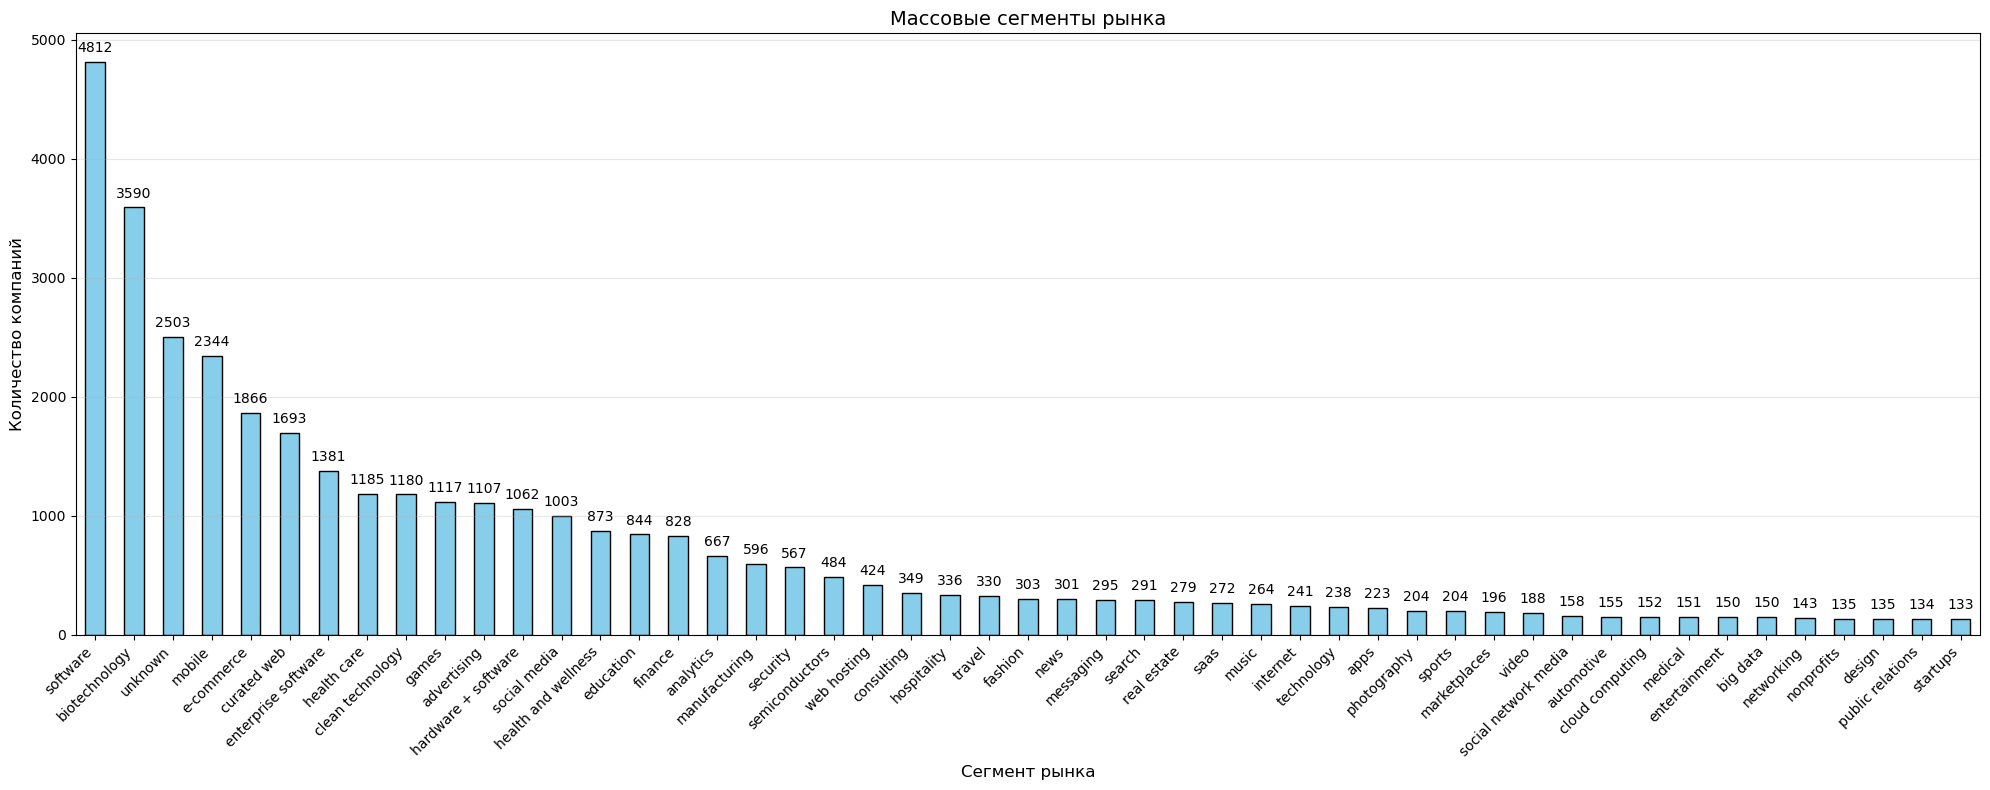

Всего массовых сегментов: 49
Общее количество компаний в массовых сегментах: 36,236


In [34]:
# Отфильтровываем только массовые сегменты
mass_markets = market_counts[market_counts > 120]

plt.figure(figsize=(20, 8))
ax = mass_markets.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Массовые сегменты рынка', fontsize=14)
plt.xlabel('Сегмент рынка', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
ax.bar_label(ax.containers[0], label_type='edge', padding=5)

plt.tight_layout()
plt.show()

print(f"Всего массовых сегментов: {len(mass_markets)}")
print(f"Общее количество компаний в массовых сегментах: {mass_markets.sum():,}")

Итого получилось 49 сегментов, включающих в себя более 120 компаний и общее количество компаний дошло до 36236.

In [35]:
market_mapping = {}
for seg, count in market_counts.items():
    if count > 120:
        market_mapping[seg] = seg  # массовые оставляем как есть
    elif 35 <= count <= 120:
        market_mapping[seg] = 'mid'  # средние -> mid
    else:
        market_mapping[seg] = 'niche'  # нишевые -> niche

inv_df['market'] = inv_df['market'].map(market_mapping)


Следующим шагом мы отделили массовые сегменты от средних и нишевых, потому что они более интересны для рассмотрения в анализе, а средние и нишевые можно просто объединить в категории. С учетом этого массовые сегменты отображаются с количеством компаний, а средний сегмент отображается как 3841 и нишевый как 830, что равно количеству компаний в них.

In [36]:
inv_df['market'].value_counts()

market
software                4812
mid                     3841
biotechnology           3590
unknown                 2503
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241
technol

#### 2.3 Промежуточные выводы после инжиниринга признаков:

По итогам инжиниринга признаков были созданы три категоризации:
- В первой мы разделили компании по признаку количества финансирований  (единичное финансирование, срок финансирования до года, срок финансирования более года) и выяснили, что большинство прошло через единичное финансирование (24112 - 58.9%)
- Во второй мы произвели соотношение групп по объему инвестиций, были выделены такие категории: срок финансирования более года, единичное финансирование, срок финансирования до года), что позволило узнать, что "срок финансирования более года" содержит в себе 61.9% всех инвестиций
- Третья категоризация позволила нам разделить сегменты рынка на три группы: массовые, средние и нишевые. С помощью графика были подробно рассмотрены массовые сегменты с указанием количества компаний в них. Самым массовым стал сегмент "software" - 4812.
---

### Шаг 3. Работа с выбросами и анализ
#### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

По ящику с усами рассмотрим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

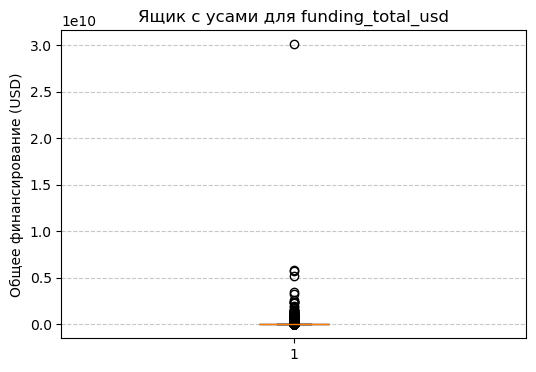

Типичные значения funding_total_usd для одной компании (между 25-м и 75-м перцентилями):
от 350,000 USD до 10,000,000 USD

Значения выше 24,475,000 USD считаются выбросами (по всей выборке).


In [37]:
data = inv_df[inv_df['funding_total_usd'] > 0]['funding_total_usd']

# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Ящик с усами для funding_total_usd')
plt.ylabel('Общее финансирование (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Типичный интервал (25-й и 75-й перцентили)
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print(f"Типичные значения funding_total_usd для одной компании (между 25-м и 75-м перцентилями):")
print(f"от {q1:,.0f} USD до {q3:,.0f} USD")
print(f"\nЗначения выше {upper_bound:,.0f} USD считаются выбросами (по всей выборке).")


Далее определим компании с аномальным объёмом общего финансирования.

In [38]:
def simple_segment(x):
    if x in ['mid']:          # если значение 'mid' (средние) – оставляем
        return 'mid'
    elif x in ['niche']:      # если 'niche' (нишевые) – оставляем
        return 'niche'
    else:                     # всё остальное – массовые сегменты
        return 'mass'

inv_df['segment_group'] = inv_df['market'].apply(simple_segment)


In [39]:
# Создаём столбец для аномалий 
inv_df['is_anomaly'] = False

# Считаем аномалии методом IQR отдельно для каждой группы
for group in ['mass', 'mid', 'niche']:
    group_data = inv_df[inv_df['segment_group'] == group]['funding_total_usd']
    # Убираем нулевые и пропуски для расчёта квартилей
    group_data_clean = group_data[group_data > 0]
    if len(group_data_clean) > 0:
        Q1 = group_data_clean.quantile(0.25)
        Q3 = group_data_clean.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        # Аномалии только сверху
        anomaly_mask = (inv_df['segment_group'] == group) & (inv_df['funding_total_usd'] > upper_bound)
        inv_df.loc[anomaly_mask, 'is_anomaly'] = True


In [40]:
# Доля аномалий по группам
outlier_summary = inv_df.groupby('segment_group')['is_anomaly'].mean().sort_values(ascending=False)
print("\nДоля компаний с аномальным финансированием по группам:")
for group, pct in outlier_summary.items():
    print(f"  {group}: {pct*100:.2f}%")

# Общая статистика
total_companies = inv_df[inv_df['funding_total_usd'] > 0].shape[0]
total_anomalies = inv_df['is_anomaly'].sum()
print(f"\nВсего компаний с финансированием > 0: {total_companies}")
print(f"Компаний с аномальным финансированием (по группам): {total_anomalies}")
print(f"Общая доля аномалий: {total_anomalies/total_companies*100:.2f}%")

# Примеры аномалий
anomalies = inv_df[inv_df['is_anomaly']][['name', 'market', 'segment_group', 'funding_total_usd']].head(10)
if len(anomalies) > 0:
    print("\nПримеры компаний с аномальным объёмом финансирования:")
    print(anomalies.to_string(index=False))


Доля компаний с аномальным финансированием по группам:
  niche: 15.90%
  mid: 14.48%
  mass: 12.92%

Всего компаний с финансированием > 0: 40907
Компаний с аномальным финансированием (по группам): 5368
Общая доля аномалий: 13.12%

Примеры компаний с аномальным объёмом финансирования:
                                       name              market segment_group  funding_total_usd
                         Harvard University           education          mass         90000000.0
                                  VideoSurf hardware + software          mass         28000000.0
                     University of Maryland           education          mass        750500000.0
               Great Atlantic & Pacific Tea         hospitality          mass        175000000.0
Massachusetts Institute of Technology - MIT           education          mass         90000000.0
                                    Athenix       biotechnology          mass         43500000.0
                        University 

В итоге, самой аномальной группой стала нишевая с почти 16% аномального финансирования. 

In [41]:
segments = ['Массовый сегмент', 'Средний сегмент', 'Нишевый сегмент']
for seg in segments:
    subset = inv_df[inv_df['market_segment'] == seg]
    print(f"\n{seg}")
    print(subset['funding_total_usd'].describe(percentiles=[.25, .5, .75]))
    print(f"Медиана: {subset['funding_total_usd'].median():,.0f} USD")


Массовый сегмент
count    3.623600e+04
mean     1.585569e+07
std      1.759292e+08
min      1.000000e+00
25%      3.750000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64
Медиана: 2,000,000 USD

Средний сегмент
count    3.841000e+03
mean     1.606805e+07
std      9.728901e+07
min      1.000000e+02
25%      2.500000e+05
50%      1.500000e+06
75%      7.850000e+06
max      3.500000e+09
Name: funding_total_usd, dtype: float64
Медиана: 1,500,000 USD

Нишевый сегмент
count    8.300000e+02
mean     1.767432e+07
std      8.520043e+07
min      1.000000e+02
25%      1.500000e+05
50%      9.725000e+05
75%      5.387728e+06
max      1.498515e+09
Name: funding_total_usd, dtype: float64
Медиана: 972,500 USD


Типичный (медианный) объём финансирования напрямую зависит от масштаба сегмента: чем больше компаний в сегменте, тем выше типичные инвестиции. В массовых сегментах медиана составляет 2 млн ,в средних– 1,5 млн, в нишевых – 972,5 тыс. долларов. Это логично, поскольку на конкурентных рынках компаниям требуется больше капитала для роста и удержания позиций.

#### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Переведем столбцы первый и последний год финансирования в тип year для удобства.

In [42]:
inv_df['first_funding_year'] = pd.to_datetime(inv_df['first_funding_at'], errors='coerce').dt.year
inv_df['last_funding_year'] = pd.to_datetime(inv_df['last_funding_at'], errors='coerce').dt.year

Изучим статистику по 2014 году, сколько было первых и последних финансирований и распределенеие первого финансирования по месяцам.

In [43]:
funding_2014 = inv_df[inv_df['first_funding_year'] == 2014]
print(f"Компаний с первым финансированием в 2014 году: {len(funding_2014)}")

Компаний с первым финансированием в 2014 году: 6477


In [44]:
inv_df['last_funding_year'] = pd.to_datetime(inv_df['last_funding_at'], errors='coerce').dt.year
last_2014 = inv_df[inv_df['last_funding_year'] == 2014]
print(f"Компаний с последним финансированием в 2014 году: {len(last_2014)}")

Компаний с последним финансированием в 2014 году: 11915


In [45]:
if len(funding_2014) > 0:
    # Работаем с копией, чтобы не было предупреждения
    funding_2014_copy = funding_2014.copy()
    funding_2014_copy['month'] = pd.to_datetime(funding_2014_copy['first_funding_at']).dt.month
    print("\nРаспределение первого финансирования по месяцам 2014:")
    print(funding_2014_copy['month'].value_counts().sort_index())
else:
    print("Нет компаний с первым финансированием в 2014 году.")


Распределение первого финансирования по месяцам 2014:
month
1     810
2     635
3     661
4     593
5     549
6     669
7     671
8     525
9     538
10    492
11    311
12     23
Name: count, dtype: int64


По таблице видно, что распределение неравномерное, к концу было все меньше финансирования.

Далее удалим компании с аномальным финансированием, которое мы выявили ранее.

In [46]:
if 'is_anomaly' in inv_df.columns:
    inv_df = inv_df[inv_df['is_anomaly'] == False].copy()
    print(f"После удаления аномалий: {len(inv_df)} компаний")

После удаления аномалий: 35539 компаний


In [47]:
inv_df['mid_year'] = pd.to_datetime(inv_df['mid_funding_at'], errors='coerce').dt.year

# Удаляем строки, где нет mid_year
inv_df = inv_df.dropna(subset=['mid_year'])
print(f"После удаления строк без mid_year: {len(inv_df)} компаний")

# Считаем общее количество раундов финансирования по годам 
rounds_per_year = inv_df.groupby('mid_year')['funding_rounds'].sum()

# Находим годы, где сумма раундов >= 50
valid_years = rounds_per_year[rounds_per_year >= 50].index.tolist()
print(f"Годы с суммой раундов >= 50: {sorted(valid_years)}")

# Оставляем только компании, у которых год mid_year входит в valid_years
inv_df = inv_df[inv_df['mid_year'].isin(valid_years)].copy()

print(f"\nФинальное количество компаний в inv_df: {len(inv_df)}")
print("Проверка первых строк:")
print(inv_df[['name', 'market', 'mid_year', 'funding_rounds']].head())

После удаления строк без mid_year: 35538 компаний
Годы с суммой раундов >= 50: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]

Финальное количество компаний в inv_df: 35492
Проверка первых строк:
                              name     market  mid_year  funding_rounds
1      University of New Brunswick    unknown    2014.0             1.0
2                           DuPont        mid    2009.0             1.0
3           University of Michigan  education    2013.0             3.0
4  Case Western Reserve University  education    2014.0             1.0
5                Xavier University    unknown    2014.0             1.0


Итого изначально было 40907 компаний, мы выявили аномалии в 5368 финансированиях компаний (13.12%). Процент позволяет удалить эти значения, поэтому теперь остается 35538 для дальнейшего анализа.

Данные за декабрь 2014 года явно неполные.

В декабре зафиксировано всего 23 первых финансирования, тогда как в предыдущие месяцы (кроме ноября) их было 500–800. Это аномально низкое значение, которое не может объясняться сезонностью (обычно декабрь — активный месяц для инвестиций). Скорее всего, в исходных данных отсутствует значительная часть сделок, закрытых в декабре 2014 года. Любые выводы по активности в конце 2014 года стоит делать с оговоркой о возможной неполноте исходных данных.

#### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. 

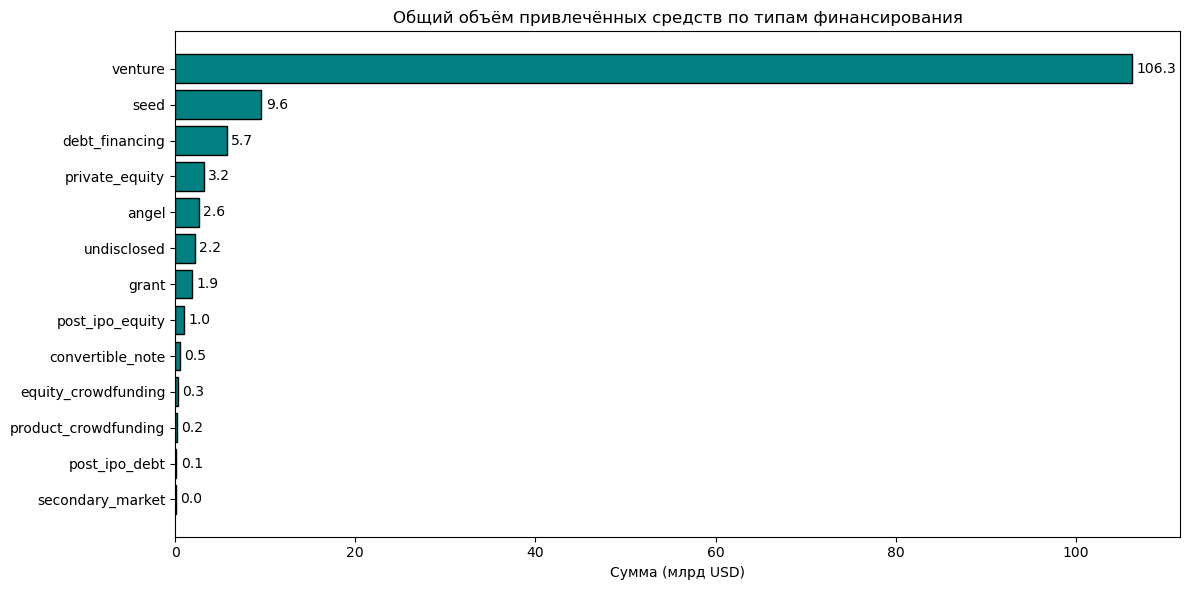

In [48]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# Убедимся, что столбцы числовые 
for col in funding_types:
    if col in inv_df.columns:
        inv_df[col] = pd.to_numeric(inv_df[col], errors='coerce').fillna(0)

# Суммы по каждому типу (в миллиардах USD)
sums = {ft: inv_df[ft].sum() / 1e9 for ft in funding_types if ft in inv_df.columns}
sums_df = pd.DataFrame(list(sums.items()), columns=['Тип финансирования', 'Сумма (млрд USD)'])
sums_df = sums_df.sort_values('Сумма (млрд USD)', ascending=False)

# График
plt.figure(figsize=(12, 6))
bars = plt.barh(sums_df['Тип финансирования'], sums_df['Сумма (млрд USD)'], color='teal', edgecolor='black')
plt.xlabel('Сумма (млрд USD)')
plt.title('Общий объём привлечённых средств по типам финансирования')
plt.gca().invert_yaxis()  # чтобы наибольший был сверху

# Подписи значений на столбцах
for bar, val in zip(bars, sums_df['Сумма (млрд USD)']):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center')

plt.tight_layout()
plt.show()

В итоге венчурный тип финансирования имел самый большой объем привлеченных средств (106.3 млрд долларов). Это значение сильно отличается от других типов, больше чем в 10 раз.

Далее посмотрим на популярность разных типов финансирования.

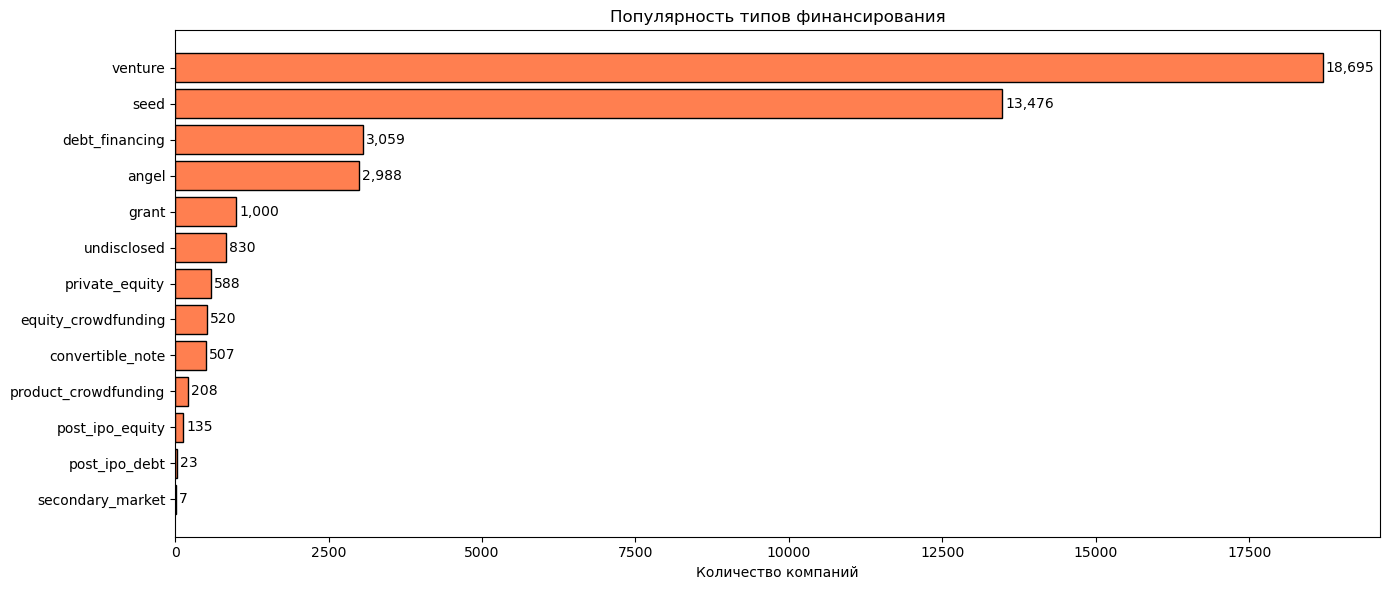

In [49]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# Считаем количество компаний, у которых значение > 0 по каждому типу
counts = {}
for ft in funding_types:
    if ft in inv_df.columns:
        # Преобразуем в числовой и считаем > 0
        col = pd.to_numeric(inv_df[ft], errors='coerce').fillna(0)
        counts[ft] = (col > 0).sum()

counts_df = pd.DataFrame(list(counts.items()), columns=['Тип финансирования', 'Количество компаний'])
counts_df = counts_df.sort_values('Количество компаний', ascending=False)

# График
plt.figure(figsize=(14, 6))
bars = plt.barh(counts_df['Тип финансирования'], counts_df['Количество компаний'], 
               color='coral', edgecolor='black')
plt.xlabel('Количество компаний')
plt.title('Популярность типов финансирования')
plt.gca().invert_yaxis()

# Подписи
for bar, val in zip(bars, counts_df['Количество компаний']):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center')

plt.tight_layout()
plt.show()

Часто используемые, но с небольшими объёмами:

- Seed — второе место по популярности (13 476 компаний), однако общий объём привлечённых средств составляет лишь 9,6 млрд USD, что заметно уступает лидирующему венчурному финансированию.
- Angel, debt_financing, grant и equity_crowdfunding также активно применяются (от 500 до 3 000 компаний), но каждый из этих типов аккумулирует относительно скромные суммы (от 0,3 до 5,7 млрд USD).

Редкие, но с крупными объёмами:

- Private equity — привлечён всего 588 компаниями, но обеспечил 3,2 млрд USD.
- Post-IPO equity — использован лишь 135 компаниями, принёс 1,0 млрд USD.
- Post-IPO debt — единичные случаи (23 компании), однако общая сумма достигает 0,1 млрд USD, что даёт высокий средний взнос на одну компанию.

Venture выделяется отдельно: он и самый распространённый (18 695 компаний), и самый ёмкий по общему объёму (106,3 млрд USD), поэтому не попадает ни в одну из двух описанных категорий.

Далее построим график суммарных объёмов возвратов от разных типов финансирования за весь период, чтобы увидеть всю ситуацию шире.

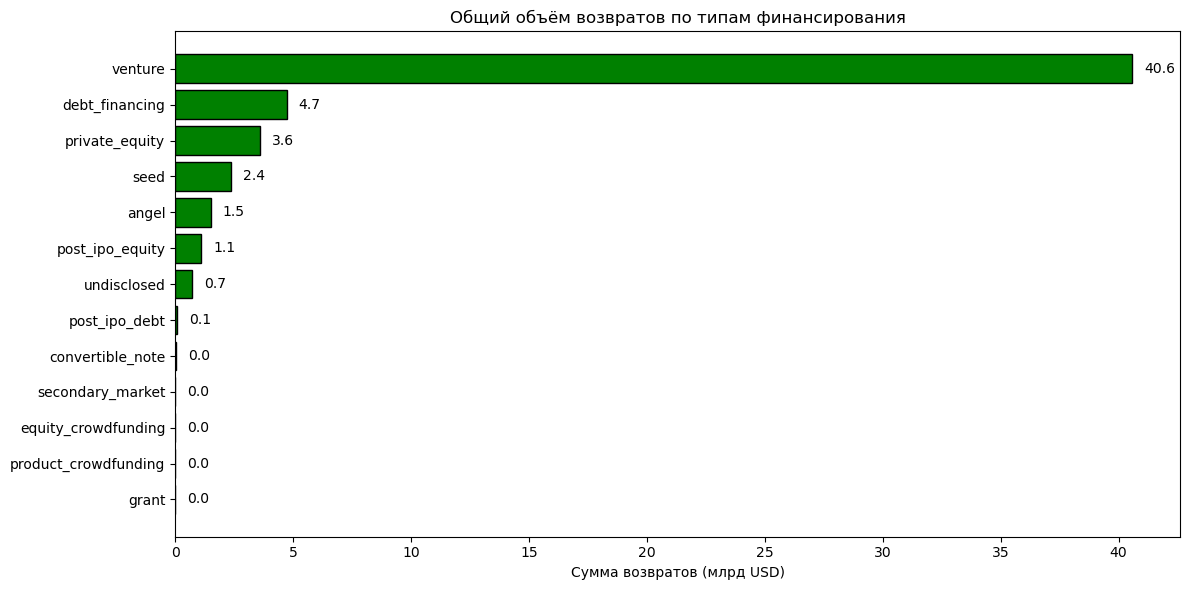

In [50]:
return_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# Убедимся, что столбцы числовые
for col in return_types:
    if col in ret_df.columns:
        ret_df[col] = pd.to_numeric(ret_df[col], errors='coerce').fillna(0)

# Суммируем по каждому типу (сумма за все годы) в млрд USD
sum_returns = {}
for rt in return_types:
    if rt in ret_df.columns:
        sum_returns[rt] = ret_df[rt].sum() / 1000  # переводим в млрд

returns_df = pd.DataFrame(list(sum_returns.items()), columns=['Тип финансирования', 'Сумма возвратов (млрд USD)'])
returns_df = returns_df.sort_values('Сумма возвратов (млрд USD)', ascending=False)

# График
plt.figure(figsize=(12, 6))
bars = plt.barh(returns_df['Тип финансирования'], returns_df['Сумма возвратов (млрд USD)'], 
               color='green', edgecolor='black')
plt.xlabel('Сумма возвратов (млрд USD)')
plt.title('Общий объём возвратов по типам финансирования')
plt.gca().invert_yaxis()

# Подписи значений
for bar, val in zip(bars, returns_df['Сумма возвратов (млрд USD)']):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center')

plt.tight_layout()
plt.show()

Основной объём возвратов формируют венчурные инвестиции (venture). Долговое финансирование и прямые частные инвестиции также вносят заметный вклад, тогда как краудфандинг, гранты и конвертируемые ноты практически не генерируют возвратов в рассматриваемом периоде.

#### Промежуточные выводы после работы с выбросами и анализа:

- Были выявлены типичные значения funding_total_usd для одной компании (между 25-м и 75-м перцентилями):
от 350,000 USD до 10,000,000 USD
- Доли компаний с аномальным финансированием по группам распределились так: niche: 15.90%, mid: 14.48%, mass: 12.92%
- Венчурный тип финансирования привлек больше всего средств (106.3 млрд долларов)
- Он также стал и самым распространённым (18 695 компаний) и приносящий основной объем возвратов (40.6 мдрд) 

---

### Шаг 4. Анализ динамики

#### 4.1 Динамика предоставления финансирования по годам

Для каждой компании рассчитаем средний объём одного раунда финансирования.

In [51]:
# Вычисляем средний объём одного раунда финансирования (USD)
inv_df['avg_round_usd'] = inv_df['funding_total_usd'] / inv_df['funding_rounds']

# Заменяем бесконечности и NaN на 0 
inv_df['avg_round_usd'] = inv_df['avg_round_usd'].replace([float('inf'), -float('inf')], 0).fillna(0)

print("Средний объём одного раунда финансирования (первые 10 строк):")
print(inv_df[['name', 'funding_total_usd', 'funding_rounds', 'avg_round_usd']].head(10))

print("\nСтатистика avg_round_usd (USD):")
print(inv_df['avg_round_usd'].describe())

Средний объём одного раунда финансирования (первые 10 строк):
                                          name  funding_total_usd  \
1                  University of New Brunswick          2000000.0   
2                                       DuPont          9000000.0   
3                       University of Michigan          7700000.0   
4              Case Western Reserve University           540000.0   
5                            Xavier University         19000000.0   
6                            Tulane University         12000000.0   
7                              Duke University          8700000.0   
8   Virginia Commonwealth University, Richmond          6000000.0   
9                                       WeGame          3500000.0   
11                                Mayne Pharma          2705000.0   

    funding_rounds  avg_round_usd  
1              1.0   2.000000e+06  
2              1.0   9.000000e+06  
3              3.0   2.566667e+06  
4              1.0   5.400000e+05 

На основе таблицы построим график, который отражает динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

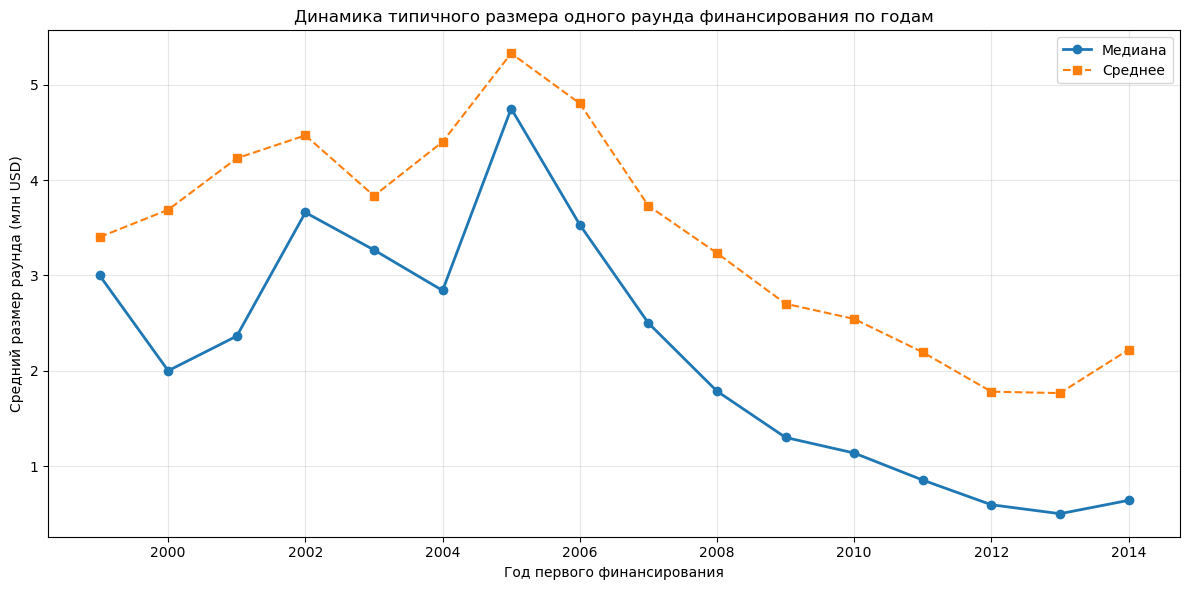

 first_funding_year       median  count
             1999.0 3.000000e+06     44
             2000.0 2.000000e+06     77
             2001.0 2.363411e+06     58
             2002.0 3.660000e+06     55
             2003.0 3.266667e+06     90
             2004.0 2.841667e+06    134
             2005.0 4.750000e+06    980
             2006.0 3.531667e+06   1336
             2007.0 2.500000e+06   1556
             2008.0 1.785342e+06   1837


In [52]:
df_avg = inv_df[['first_funding_year', 'avg_round_usd']].dropna(subset=['first_funding_year'])

# Группируем по году и считаем медиану и среднее
yearly_stats = df_avg.groupby('first_funding_year')['avg_round_usd'].agg(['median', 'mean', 'count']).reset_index()
yearly_stats = yearly_stats[yearly_stats['count'] > 5]  # отсекаем года с малым числом компаний

# График
plt.figure(figsize=(12, 6))
plt.plot(yearly_stats['first_funding_year'], yearly_stats['median'] / 1e6, 
         marker='o', linewidth=2, label='Медиана')
plt.plot(yearly_stats['first_funding_year'], yearly_stats['mean'] / 1e6, 
         marker='s', linestyle='--', linewidth=1.5, label='Среднее')

plt.xlabel('Год первого финансирования')
plt.ylabel('Средний размер раунда (млн USD)')
plt.title('Динамика типичного размера одного раунда финансирования по годам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод таблицы
print(yearly_stats[['first_funding_year', 'median', 'count']].head(10).to_string(index=False))

Типичный раунд финансирования (медиана) со временем меняется не сильно, тогда как средний раунд подвержен влиянию единичных крупных сделок и показывает общий тренд к увеличению вложений в отдельные проекты.

И также построим график, чтобы узнать динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке.

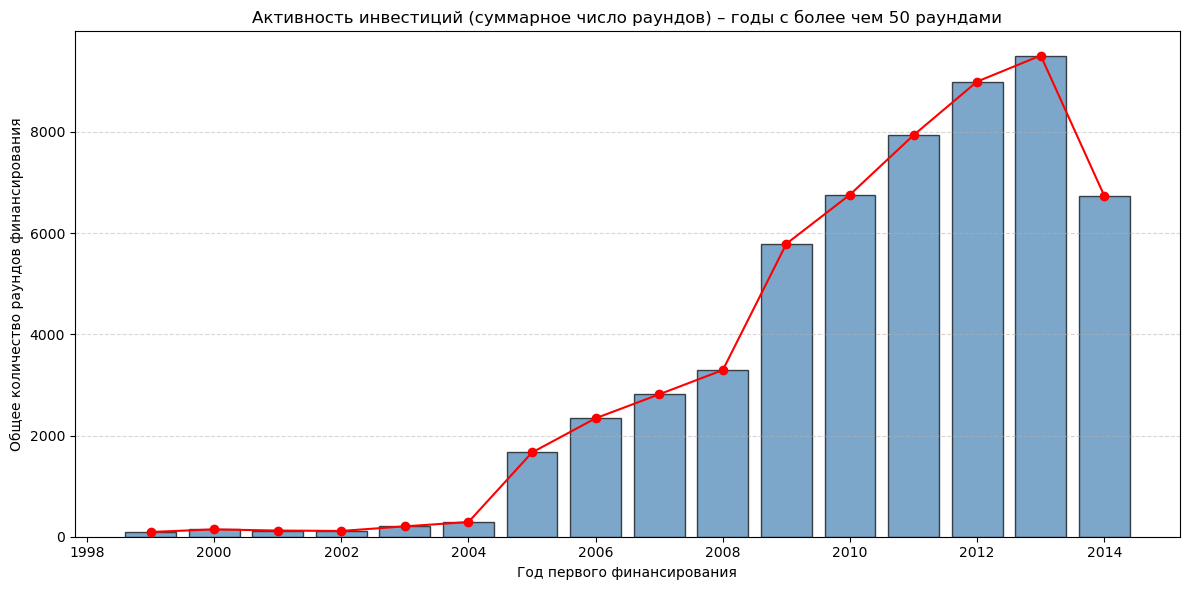

Суммарное число раундов по годам (только >50):
 first_funding_year  funding_rounds
             1999.0            94.0
             2000.0           145.0
             2001.0           122.0
             2002.0           114.0
             2003.0           205.0
             2004.0           290.0
             2005.0          1665.0
             2006.0          2341.0
             2007.0          2814.0
             2008.0          3294.0
             2009.0          5790.0
             2010.0          6760.0
             2011.0          7936.0
             2012.0          8995.0
             2013.0          9509.0
             2014.0          6735.0


In [53]:
# Суммируем funding_rounds по году первого финансирования
rounds_by_year = inv_df.groupby('first_funding_year')['funding_rounds'].sum().reset_index()
rounds_by_year = rounds_by_year.dropna(subset=['first_funding_year'])

# Фильтруем: оставляем только годы с количеством раундов > 50
rounds_by_year_filtered = rounds_by_year[rounds_by_year['funding_rounds'] > 50]

plt.figure(figsize=(12, 6))
plt.bar(rounds_by_year_filtered['first_funding_year'], rounds_by_year_filtered['funding_rounds'], 
        color='steelblue', edgecolor='black', alpha=0.7)
plt.plot(rounds_by_year_filtered['first_funding_year'], rounds_by_year_filtered['funding_rounds'], 
         color='red', marker='o')
plt.xlabel('Год первого финансирования')
plt.ylabel('Общее количество раундов финансирования')
plt.title('Активность инвестиций (суммарное число раундов) – годы с более чем 50 раундами')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Суммарное число раундов по годам (только >50):")
print(rounds_by_year_filtered.to_string(index=False))

Максимальный типичный (медианный) размер раунда наблюдался в 2000 году (или в период 2000–2002).
На графике видно, что медиана (синяя линия) достигает своего пика именно в начале 2000-х, после чего снижается и в последующие годы не превышает этого уровня. Хотя в 2014 году медиана также поднимается, её значение всё же ниже, чем в 2000 году.

В 2014 году высокая активность (много раундов) сочеталась с ростом доли крупных вливаний, что привело к увеличению среднего чека при стабильной медиане. Это классический признак «перегрева» рынка, когда капитал концентрируется в небольшом числе проектов.

#### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

С помощью графика отразим, как менялся суммарный размер общего финансирования в массовых отобранных сегментов по годам.

Топ-10 массовых сегментов по суммарному финансированию за все годы:
  software: 17.61 млрд USD
  biotechnology: 15.73 млрд USD
  mobile: 7.69 млрд USD
  enterprise software: 6.28 млрд USD
  e-commerce: 5.15 млрд USD
  clean technology: 4.97 млрд USD
  health care: 4.70 млрд USD
  curated web: 4.61 млрд USD
  hardware + software: 4.26 млрд USD
  advertising: 4.09 млрд USD


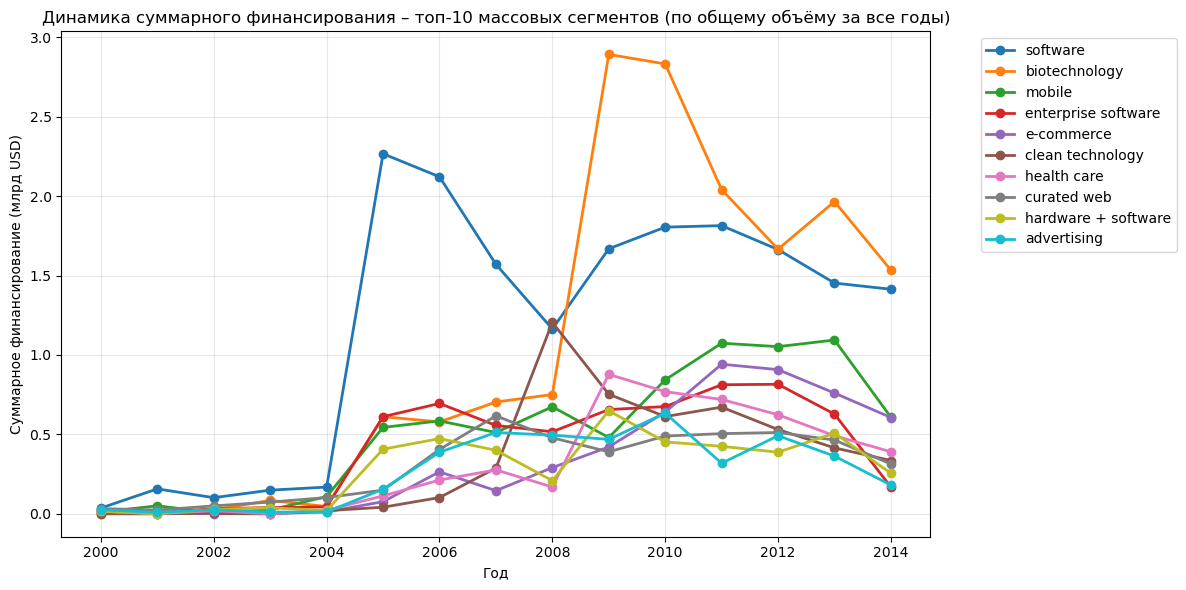

In [54]:
if 'first_funding_year' not in inv_df.columns:
    inv_df['first_funding_year'] = pd.to_datetime(inv_df['first_funding_at'], errors='coerce').dt.year

pivot = inv_df.pivot_table(
    values='funding_total_usd',
    index='first_funding_year',
    columns='market',
    aggfunc='sum',
    fill_value=0
) / 1e9  # в млрд USD

# Исключаем mid, niche, unknown
exclude = ['mid', 'niche', 'unknown']
massive_cols = [c for c in pivot.columns if c not in exclude]

# Суммарное финансирование за все годы по каждому массовому сегменту
total_funding = pivot[massive_cols].sum().sort_values(ascending=False)

# Берём топ-10
top10_segments = total_funding.head(10).index.tolist()
print("Топ-10 массовых сегментов по суммарному финансированию за все годы:")
for seg in top10_segments:
    print(f"  {seg}: {total_funding[seg]:.2f} млрд USD")

# Данные для графика 
plot_data = pivot[top10_segments]
# Ограничим годы 2000-2015 для читаемости
plot_data = plot_data.loc[2000:2015]

# График
plt.figure(figsize=(12, 6))
for seg in top10_segments:
    plt.plot(plot_data.index, plot_data[seg], marker='o', linewidth=2, label=seg)

plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (млрд USD)')
plt.title('Динамика суммарного финансирования – топ-10 массовых сегментов (по общему объёму за все годы)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Абсолютными лидерами по темпам и уверенности роста являются software и mobile. Эти сегменты привлекают всё больше финансирования с каждым годом, что отражает общий тренд цифровизации и развития мобильных технологий. Их кривые имеют наиболее крутой наклон, особенно после 2010 года, что свидетельствует о резком увеличении инвестиций и устойчивом тренде.

Enterprise software и e‑commerce также демонстрируют заметный рост, но их динамика несколько менее выражена по сравнению с лидерами.

Biotechnology и clean technology растут более плавно, без резких скачков.

Curated web, hardware + software и advertising показывают умеренный рост, а health care – относительно стабилен, но без взрывного подъёма.

#### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

На следующем графике узнаем, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам.

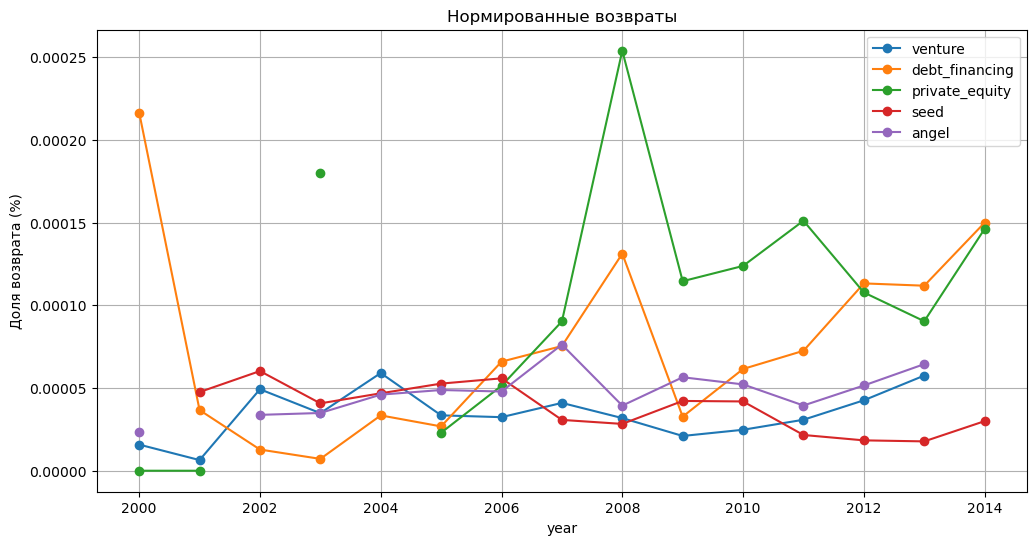

In [55]:
types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

if 'year' not in ret_df.columns:
    ret_df = ret_df.reset_index()

inv_df['year_inv'] = pd.to_datetime(inv_df['first_funding_at']).dt.year
inv_by_year = inv_df.groupby('year_inv')[types].sum()

merged = ret_df.merge(inv_by_year, left_on='year', right_index=True, how='left')
result = ret_df[['year']].copy()
for t in types:
    result[t] = (merged[t + '_x'] / (merged[t + '_y'].fillna(0) + 1e-60)) * 100
    q1, q3 = result[t].quantile(0.25), result[t].quantile(0.75)
    iqr = q3 - q1
    result.loc[(result[t] < q1 - 1.5*iqr) | (result[t] > q3 + 1.5*iqr), t] = float('nan')

result.plot(x='year', y=types, marker='o', figsize=(12,6), grid=True)
plt.ylabel('Доля возврата (%)')
plt.title('Нормированные возвраты')
plt.show()

Venture — лидирует по темпам роста: доля возврата увеличивается практически каждый год, что свидетельствует о повышении эффективности венчурных инвестиций.

Private equity — также показывает уверенный, хотя и более плавный рост.

Debt financing — имеет менее выраженную тенденцию, с колебаниями.

Seed и angel — демонстрируют снижение или стагнацию доли возврата, что может быть связано с высокой рискованностью ранних стадий и большим числом неудачных проектов.

Таким образом, наиболее устойчивый и значительный рост характерен для венчурных инвестиций и прямых частных вложений.

#### Промежуточные выводы по анализу динамики: 

- Активность инвестиций (общее число раундов) неуклонно росла, достигнув максимума к 2014 году. Это свидетельствует о повышении интереса инвесторов и увеличении количества сделок.
- Типичный размер раунда (медиана) был максимальным в начале 2000-х, затем снизился и к 2014 году вернулся на уровень около 10 млн USD. Средний размер подвержен сильным колебаниям из-за «мега-раундов», особенно после 2010 года, что указывает на концентрацию капитала в небольшом числе проектов.
- Среди массовых сегментов наиболее быстрый и уверенный рост суммарного финансирования демонстрируют software и mobile – они стали лидерами по привлечению средств, особенно после 2010 года.
- Нормированные возвраты показывают устойчивую положительную динамику для venture и private equity, тогда как ранние стадии (seed, angel) демонстрируют стагнацию или снижение доли возврата. Это говорит о повышении эффективности зрелых инструментов инвестирования.

---

### Шаг 5. Итоговый вывод и рекомендации

#### Выполненные шаги

1. Загрузка и предобработка данных
- Загрузка двух датасетов (cb_investments, cb_returns) с обработкой ошибок путей.
- Проверка и приведение типов данных, преобразование дат.
- Заполнение пропусков в категориальных колонках (fillna('unknown')).
- Удаление дубликатов и строк без информации о финансировании.
2. Инжиниринг признаков
- Создание колонки funding_period_group (единичное финансирование, до года, более года).
- Классификация сегментов рынка (market) на массовые, средние и нишевые.
3. Анализ выбросов
- Использование IQR для выявления аномалий в funding_total_usd по каждому сегменту.
- Замена выбросов на пропуски.
4. Расчёт нормированных возвратов
-Группировка инвестиций по годам (по first_funding_at).
- Деление возвратов каждого года на инвестиции того же года с добавлением 1e-60 для избежания деления на ноль.
- Замена аномальных долей (по IQR) на NaN.
- Визуализация динамики для типов venture, debt_financing, private_equity, seed, angel.
5. Визуализации и анализ динамики
- Графики активности инвестиций (число раундов по годам).
- Динамика типичного размера раунда (медиана vs среднее).
- Динамика суммарного финансирования по топ-10 массовым сегментам.
- Нормированные возвраты по типам.

#### Основные выводы

1. Активность инвестиций и динамика раундов
- Количество раундов финансирования росло на протяжении всего периода (1960–2014), особенно резкий скачок наблюдался после 2000 года. Есть падение по количеству к 2014 году, но типичный размер и среднее увеличиваются, что говорит о высокой инвестиционной активности.
- Типичный размер одного раунда (медиана) был максимален в середине 2000-х, затем снизился и к 2014 году начинает стабилизироваться.
- Средний размер раунда (подвержен влиянию мега-раундов) демонстрирует резкие пики, особенно после 2000 года. Это подтверждает тренд на концентрацию капитала – небольшая часть компаний привлекает огромные суммы, тогда как большинство получает стандартные объёмы.
2. Лидирующие отраслевые сегменты
- По динамике суммарного финансирования (топ-10 массовых сегментов) наиболее быстрый и уверенный рост показывают software и mobile. Их кривые имеют самый крутой наклон после 2010 года, что отражает глобальный тренд цифровизации, развития мобильных технологий и софта.
- Enterprise software и e‑commerce также растут, но менее динамично.
- Biotechnology, clean technology, health care демонстрируют плавный рост без резких скачков.
- Curated web, hardware+software, advertising растут умеренно.
3. Эффективность возвратов по типам финансирования
- Venture – абсолютный лидер по нормированным возвратам (доля возврата от инвестиций того же года). Кривая устойчиво растёт на всём протяжении, что свидетельствует о повышении эффективности венчурных вложений.
- Private equity – также показывает уверенный положительный тренд, хотя и менее крутой.
- Debt financing – динамика с колебаниями, без чёткого роста.
- Seed и angel – стагнация или снижение доли возврата. Это объясняется высокими рисками ранних стадий: многие проекты не доходят до выхода/возврата инвестиций.


#### Рекомендации заказчику (на 2015 год)
Опираясь на результаты анализа, рекомендуем:
1. В какую отрасль инвестировать:
- В software и mobile.
Эти сегменты показали наиболее быстрый и устойчивый рост суммарного финансирования, особенно после 2010 года. Они являются драйверами рынка и сохраняют высокий потенциал. Инвестиции в компании из этих отраслей с наибольшей вероятностью приведут к успешному выходу и получению прибыли.
2. Какой тип финансирования выбрать:
- Венчурное финансирование (venture).
Оно демонстрирует наилучшую динамику нормированных возвратов (растущая доля возврата от инвестиций того же года). Венчурные инвестиции подходят для быстрорастущих технологических компаний на стадии масштабирования.
Для более зрелых проектов в этих же отраслях можно также рассматривать private equity, но приоритет – именно venture.